<a href="https://colab.research.google.com/github/arpitem/First-one/blob/master/CNN_for_Bechtel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks (CNNs) — A Field Guide for Bechtel

**From the IIT Delhi × Bechtel AI/ML Programme**

This notebook is a hands-on companion to the CNN lecture. You don't need a
software engineering background to get through this — every idea is built
up from scratch with pictures, small examples, and code you can run and
poke at.

### What you'll walk away with

1. Why looking at an image pixel-by-pixel is a bad idea, and what CNNs do instead
2. What a "convolution" actually is (it's simpler than the name suggests)
3. How a CNN learns to spot edges, shapes, and eventually objects
4. A working toy CNN that you train yourself, live, in this notebook
5. A quick tour of the famous architectures (AlexNet, VGG, GoogLeNet, ResNet)
6. How all of this maps onto real EPC use cases — PPE detection, weld/corrosion
   inspection, drawing analysis, drone progress monitoring

> **How to use this notebook:** Run the cells from top to bottom (click a
> cell, press `Shift+Enter`). Nothing here needs the internet or a GPU —
> everything trains in seconds on a laptop. Feel free to change numbers and
> re-run cells to see what happens — that's the best way to build intuition.


In [1]:

# Run this first. It just loads the tools we'll use throughout the notebook.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams['figure.facecolor'] = 'white'
print("All set. Libraries loaded:")
print(f"  torch   {torch.__version__}")
print(f"  numpy   {np.__version__}")


All set. Libraries loaded:
  torch   2.11.0+cpu
  numpy   2.0.2



---
## 1. Why do we need a special kind of network for images?

Before CNNs, the standard neural network was a **fully connected network**
(every input is wired to every neuron in the next layer — like a giant web
of connections). That works fine for simple tabular data (e.g. predicting a
cost overrun from 10 project metrics). But it breaks down badly for images.
Two reasons:

**Reason 1 — Way too many connections.**
A small, low-resolution 200×200 color photo has 200 × 200 × 3 = **120,000**
numbers in it (height × width × 3 color channels). If we wire that into a
modest hidden layer of just 1,000 neurons, fully connected, that's

$$120{,}000 \times 1{,}000 = 120{,}000{,}000 \text{ connections — for one layer alone.}$$

That's a huge number of values the model has to learn from a limited number
of example photos. The model basically memorizes noise instead of learning
anything useful — this is called **overfitting**.

**Reason 2 — No sense of "nearby."**
When you flatten a 2D photo into one long list of numbers to feed a fully
connected layer, you throw away the fact that a pixel and the pixel right
next to it are related. A crack in a pipe is a *pattern of nearby pixels* —
flattening destroys that pattern.

CNNs fix both problems with one idea: instead of connecting *every* pixel
to *every* neuron, slide a **small window** over the image and reuse the
same small set of weights everywhere. Let's see exactly what that means.



### Why this matters at Bechtel

> *A CNN behaves like an engineer inspecting a drawing piece by piece —
> scanning small areas, recognizing edges and shapes, and slowly building
> up to recognizing whole objects.*

This single idea is the engine behind a surprising range of EPC applications:

| Use case | What the CNN is "looking for" |
|---|---|
| **PPE detection** | Hard hats, vests, gloves, masks on a worker in a site photo |
| **Inspection** | Welds, corrosion, cracks on equipment and pipelines |
| **Document intelligence** | Symbols and text regions on P&IDs, datasheets, drawings |
| **Drone / remote sensing** | Progress monitoring, volume estimation, site mapping from aerial images |

Keep these in the back of your mind — we'll return to them at the end.



---
## 2. First things first: a computer sees an image as a grid of numbers

A grayscale image is just a 2D grid (a matrix) of numbers. Each number is a
pixel's brightness, usually from 0 (black) to 255 (white) — we'll often
work with numbers scaled between 0 and 1 instead.

A color image is the same idea, but with **3 grids stacked together** — one
each for Red, Green, and Blue. We call this stack of grids **channels**, and
the number of channels is sometimes called the image's **depth**.

- Grayscale image → depth = 1
- RGB color image → depth = 3

Let's make a tiny synthetic image and look at the raw numbers behind it.


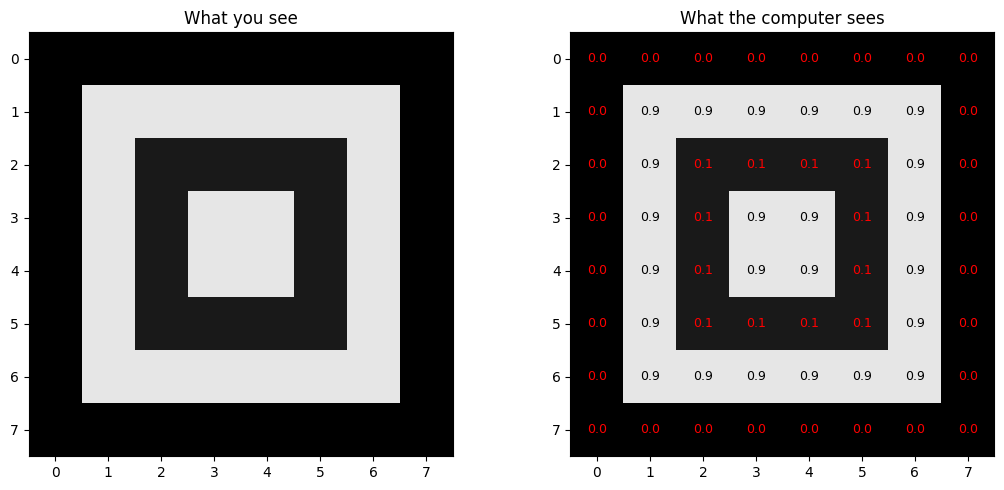

In [2]:

# A tiny 8x8 grayscale image, built by hand so we can see every number
tiny_image = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.0],
    [0.0, 0.9, 0.1, 0.1, 0.1, 0.1, 0.9, 0.0],
    [0.0, 0.9, 0.1, 0.9, 0.9, 0.1, 0.9, 0.0],
    [0.0, 0.9, 0.1, 0.9, 0.9, 0.1, 0.9, 0.0],
    [0.0, 0.9, 0.1, 0.1, 0.1, 0.1, 0.9, 0.0],
    [0.0, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(tiny_image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("What you see")
axes[0].set_xticks(range(8)); axes[0].set_yticks(range(8))

axes[1].imshow(tiny_image, cmap='gray', vmin=0, vmax=1)
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, f"{tiny_image[i,j]:.1f}", ha='center', va='center',
                     color='red' if tiny_image[i,j] < 0.5 else 'black', fontsize=9)
axes[1].set_title("What the computer sees")
axes[1].set_xticks(range(8)); axes[1].set_yticks(range(8))
plt.tight_layout()
plt.show()



That's it — that's the whole mystery of "what is an image to a computer."
A photo from a site camera, a scanned P&ID, a drone shot — all of it is
ultimately just grids of numbers like the one above (just much bigger, and
usually with 3 channels for color).



---
## 3. What is a convolution, really?

Forget the scary math name for a second. A convolution is just this:

> Take a **small grid of numbers** (called a **filter** or **kernel**),
> slide it across the image, and at every position, multiply the
> overlapping numbers together and add them up. Write that single sum into
> the output. Move the window over. Repeat.

That's the entire operation. Let's do it by hand on a tiny 3×3 example,
exactly the way it's done inside a CNN.


In [3]:

# Our "image" (just a 3x3 grid of numbers)
image_3x3 = np.array([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
])

# Our "kernel" / "filter" (a 2x2 grid of numbers, usually learned by the network)
kernel_2x2 = np.array([
    [0, 1],
    [2, 3]
])

print("Image:\n", image_3x3)
print("\nKernel:\n", kernel_2x2)

# The kernel slides over the image. With a 3x3 image and a 2x2 kernel,
# there are exactly 4 positions it can sit in (top-left, top-right, bottom-left, bottom-right)
top_left     = image_3x3[0:2, 0:2]
top_right    = image_3x3[0:2, 1:3]
bottom_left  = image_3x3[1:3, 0:2]
bottom_right = image_3x3[1:3, 1:3]

def windowed_sum(window, kernel):
    return np.sum(window * kernel)

output = np.array([
    [windowed_sum(top_left, kernel_2x2),    windowed_sum(top_right, kernel_2x2)],
    [windowed_sum(bottom_left, kernel_2x2), windowed_sum(bottom_right, kernel_2x2)]
])

print("\nOutput (the 'feature map'):\n", output)


Image:
 [[0 1 2]
 [3 4 5]
 [6 7 8]]

Kernel:
 [[0 1]
 [2 3]]

Output (the 'feature map'):
 [[19 25]
 [37 43]]



Notice the output is **smaller** than the input (2×2 instead of 3×3) — sliding
a 2×2 window over a 3×3 grid only gives 4 valid positions. We'll come back to
this "shrinking" effect shortly (and how to control it with **padding**).

Let's write a general-purpose convolution function so we can experiment with
any image size and any kernel size, and reuse it for the rest of the notebook.


In [4]:

def convolve2d(image, kernel, stride=1, padding=0):
    '''A from-scratch 2D convolution (technically cross-correlation, which is
    what every deep learning library actually implements under the hood).

    image:   2D numpy array (H x W)
    kernel:  2D numpy array (kh x kw)
    stride:  how many pixels to move the window each step
    padding: how many rows/cols of zeros to add around the border first
    '''
    if padding > 0:
        image = np.pad(image, padding, mode='constant')

    H, W = image.shape
    kh, kw = kernel.shape
    out_h = (H - kh) // stride + 1
    out_w = (W - kw) // stride + 1

    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            row, col = i * stride, j * stride
            window = image[row:row+kh, col:col+kw]
            output[i, j] = np.sum(window * kernel)
    return output

# Sanity check against the example above
result = convolve2d(image_3x3, kernel_2x2)
print("Matches our hand calculation?", np.array_equal(result, output))


Matches our hand calculation? True



### A bigger worked example, with stride

The **stride** is just how far the window jumps each time. Stride 1 means
"slide one pixel at a time" (lots of overlap, bigger output). Stride 2 means
"jump two pixels at a time" (less overlap, smaller output — like skimming
instead of reading every word).


In [5]:

# A slightly bigger example, with a real "object" inside the grid
# (the bright values 8,9,2,9,1,4 form a little blob, like a hot-spot in a thermal image)
demo_input = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,2,3,4,4,5,0],
    [0,6,0,7,8,9,0,0],
    [0,4,1,7,2,9,4,0],
    [0,9,4,9,1,4,2,0],
    [0,0,0,0,0,0,0,0]
])

demo_kernel = np.array([
    [0,1,2],
    [3,4,5],
    [6,7,8]
])

out_stride1 = convolve2d(demo_input, demo_kernel, stride=1)
out_stride2 = convolve2d(demo_input, demo_kernel, stride=2)

print("Input shape:", demo_input.shape)
print("Output shape with stride=1:", out_stride1.shape)
print("Output shape with stride=2:", out_stride2.shape)
print("\nOutput with stride=2:\n", out_stride2)


Input shape: (6, 8)
Output shape with stride=1: (4, 6)
Output shape with stride=2: (2, 3)

Output with stride=2:
 [[ 56. 151. 164.]
 [122. 159. 121.]]



There's a simple formula tying input size, kernel size, padding, and stride
to the output size — you don't need to memorize it, but it's handy to know
it exists so you're never surprised by a layer's output shape:

$$
f = \left\lfloor \frac{n - k + 2p}{s} + 1 \right\rfloor
$$

where $n$ = input size, $k$ = kernel size, $p$ = padding, $s$ = stride.
Try plugging in the numbers from the cell above ($n=8, k=3, p=0, s=2$) — you
should get $f = 3$, matching the shape we just printed.



---
## 4. Padding: stopping the image from shrinking too fast

You just saw that every convolution shrinks the image a little. If you
stack many convolution layers (which is exactly what a real CNN does),
the image would shrink and shrink until there's nothing left, and the
pixels at the edges get used far less often than pixels in the middle.

**Padding** fixes this — we just add a border of zeros around the image
before convolving, so the output can stay the same size (or shrink more
slowly, depending on how much padding we use).


Original 4x4 image:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

Same image with 1 pixel of zero-padding added around the border:
 [[ 0  0  0  0  0  0]
 [ 0  1  2  3  4  0]
 [ 0  5  6  7  8  0]
 [ 0  9 10 11 12  0]
 [ 0 13 14 15 16  0]
 [ 0  0  0  0  0  0]]


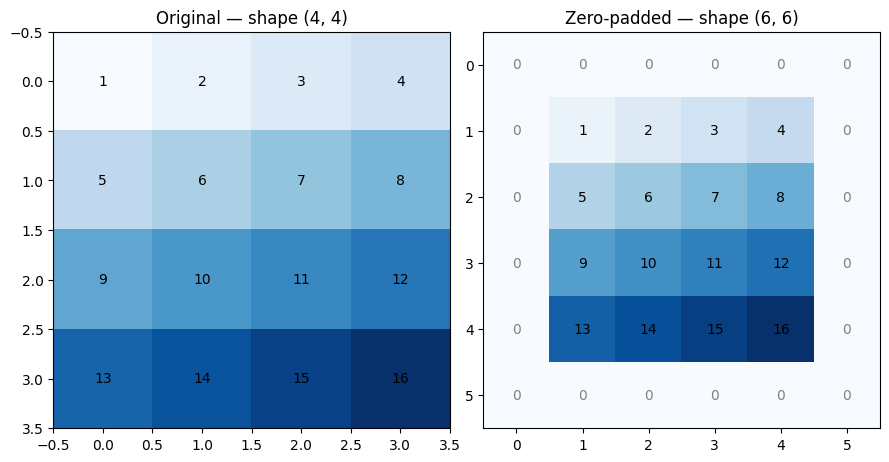

In [6]:

small_image = np.arange(1, 17).reshape(4, 4)
print("Original 4x4 image:\n", small_image)

padded_image = np.pad(small_image, pad_width=1, mode='constant')
print("\nSame image with 1 pixel of zero-padding added around the border:\n", padded_image)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(small_image, cmap='Blues')
axes[0].set_title(f"Original — shape {small_image.shape}")
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, small_image[i, j], ha='center', va='center')

axes[1].imshow(padded_image, cmap='Blues')
axes[1].set_title(f"Zero-padded — shape {padded_image.shape}")
for i in range(6):
    for j in range(6):
        axes[1].text(j, i, padded_image[i, j], ha='center', va='center',
                     color='gray' if padded_image[i,j]==0 else 'black')
plt.tight_layout()
plt.show()



With a 3×3 kernel, padding the border by 1 pixel exactly cancels out the
shrinking, so the output comes out the **same size** as the input. This is
such a common choice that it has a name: **"same" padding**.



---
## 5. The "aha" moment: different kernels see different things

This is the heart of why CNNs work. Different small kernels, slid over the
same image, light up completely different patterns — vertical edges,
horizontal edges, blurry regions, sharp boundaries. A CNN's job during
training is simply to **learn which kernels are useful** for the task at
hand, instead of us hand-designing them.

Let's build a small synthetic "site photo" — a circle standing in for a hard
hat and a rectangle standing in for a safety vest — and run some classic,
hand-designed kernels over it so you can see the effect with your own eyes.


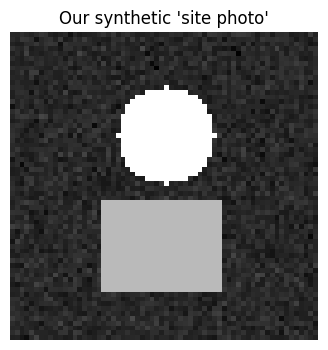

In [7]:

def make_synthetic_scene(size=64, seed=0):
    '''Builds a simple grayscale scene: a bright circle ('helmet') above a
    mid-tone rectangle ('vest'), on a slightly noisy background — a stand-in
    for a real site photo, without needing to download anything.'''
    rng = np.random.default_rng(seed)
    img = np.ones((size, size), dtype=np.float32) * 0.30
    img += rng.normal(0, 0.03, (size, size)).astype(np.float32)

    yy, xx = np.mgrid[0:size, 0:size]
    cy, cx, r = size // 3, size // 2, size // 6
    helmet_mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
    img[helmet_mask] = 0.92

    img[int(size*0.55):int(size*0.85), int(size*0.3):int(size*0.7)] = 0.72
    return np.clip(img, 0, 1)

scene = make_synthetic_scene()
plt.figure(figsize=(4, 4))
plt.imshow(scene, cmap='gray')
plt.title("Our synthetic 'site photo'")
plt.axis('off')
plt.show()


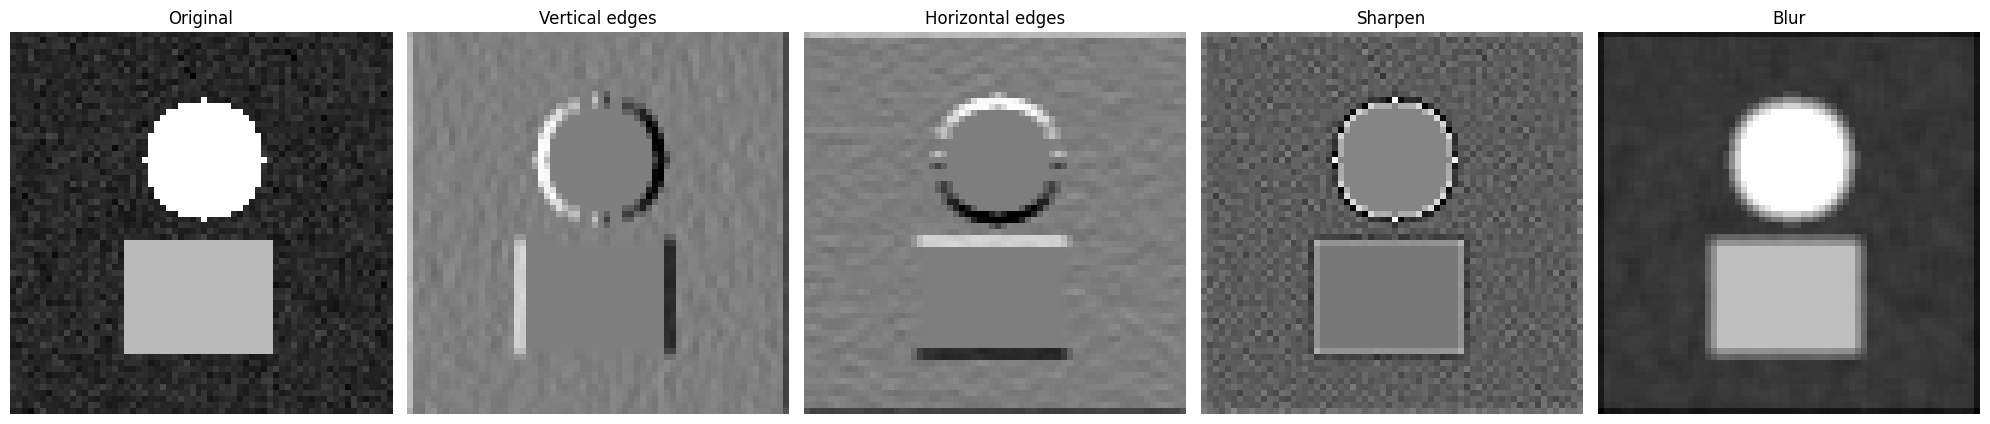

In [8]:

# A handful of classic, hand-designed kernels (no training involved yet —
# these are exactly the kind of filter a CNN would discover on its own)
kernels = {
    "Vertical edges":   np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Horizontal edges": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    "Sharpen":          np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
    "Blur":             np.ones((3, 3)) / 9,
}

fig, axes = plt.subplots(1, len(kernels) + 1, figsize=(4 * (len(kernels) + 1), 4.2))
axes[0].imshow(scene, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for ax, (name, kernel) in zip(axes[1:], kernels.items()):
    feature_map = convolve2d(scene, kernel, stride=1, padding=1)
    ax.imshow(feature_map, cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()



Look at what happened:

- The **"Vertical edges"** kernel lights up wherever brightness changes
  sharply left-to-right — the circle's left and right sides pop out.
- The **"Horizontal edges"** kernel lights up the top and bottom of the
  circle and the rectangle instead.
- **"Sharpen"** emphasizes the boundary of every shape.
- **"Blur"** smooths everything out, suppressing detail and noise.

This is exactly the principle behind **weld inspection** or **crack
detection**: a crack is a sharp, thin, high-contrast edge against a
relatively smooth background. An edge-detecting kernel is, quite literally,
a crack detector. A CNN's first layer typically learns kernels very similar
to these automatically — and its deeper layers combine many such "edge maps"
into detectors for shapes, textures, and eventually whole objects (a hard
hat, a corroded weld, a missing gauge cover).



---
## 6. Pooling: zooming out a little

After a convolution layer detects local patterns (edges, textures), we
usually shrink the feature map down a bit before the next layer. This is
called **pooling**. The most common version, **max pooling**, slides a
small window over the feature map and keeps only the **largest** value in
each window.

Why does this help?

- It reduces the amount of computation needed in later layers.
- It makes the network a little more tolerant of *where exactly* a feature
  sits — if the crack shifts by a pixel or two, max pooling still picks it up.

Pooling has **no learnable weights** — it's a fixed, simple operation. There
is also **average pooling** (it takes the average instead of the max), used
in a few specific places we'll see later.


In [9]:

def max_pool2d(feature_map, pool_size=2, stride=2):
    H, W = feature_map.shape
    out_h = (H - pool_size) // stride + 1
    out_w = (W - pool_size) // stride + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            row, col = i * stride, j * stride
            window = feature_map[row:row+pool_size, col:col+pool_size]
            output[i, j] = np.max(window)
    return output

pool_demo_input = np.array([
    [1, 2, 3, 4, 4, 5],
    [6, 0, 7, 8, 9, 0],
    [4, 1, 7, 2, 9, 4],
    [9, 4, 9, 1, 4, 2]
])

pooled = max_pool2d(pool_demo_input, pool_size=2, stride=2)
print("Before pooling, shape", pool_demo_input.shape, ":\n", pool_demo_input)
print("\nAfter 2x2 max pooling (stride 2), shape", pooled.shape, ":\n", pooled)


Before pooling, shape (4, 6) :
 [[1 2 3 4 4 5]
 [6 0 7 8 9 0]
 [4 1 7 2 9 4]
 [9 4 9 1 4 2]]

After 2x2 max pooling (stride 2), shape (2, 3) :
 [[6. 8. 9.]
 [9. 9. 9.]]



Each number in the output is just the loudest ("max") signal from its little
2×2 neighborhood in the input. The feature map shrinks from 4×6 down to
2×3 — a quarter of the data, while keeping the strongest signals.

Let's see this visually on our synthetic scene's edge map from before.


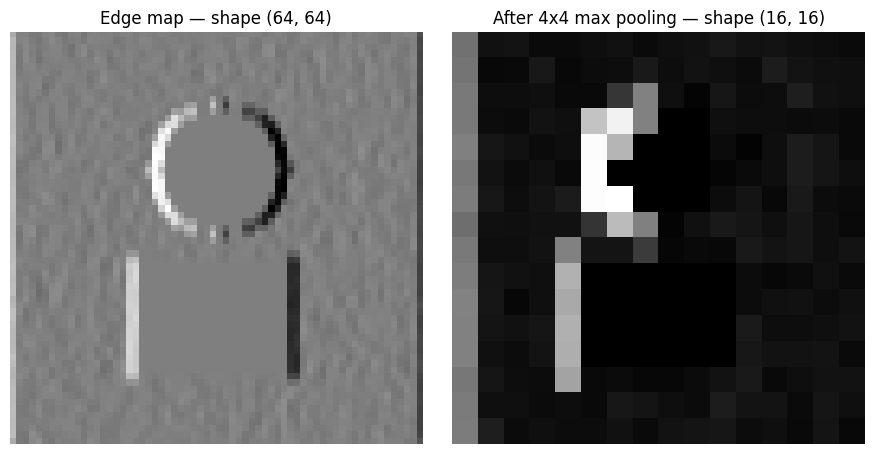

In [10]:

vertical_edges = convolve2d(scene, kernels["Vertical edges"], stride=1, padding=1)
pooled_edges = max_pool2d(vertical_edges, pool_size=4, stride=4)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(vertical_edges, cmap='gray')
axes[0].set_title(f"Edge map — shape {vertical_edges.shape}")
axes[0].axis('off')
axes[1].imshow(pooled_edges, cmap='gray')
axes[1].set_title(f"After 4x4 max pooling — shape {pooled_edges.shape}")
axes[1].axis('off')
plt.tight_layout()
plt.show()



The pooled version is much smaller, but the helmet and vest outlines are
still clearly visible — we threw away a lot of pixels but kept the
important structure. That's the whole point of pooling.



---
## 7. Putting it all together: a complete CNN

So a CNN is just a stack of the building blocks we've already covered,
repeated a few times, finishing with a small fully-connected section that
turns the final features into a decision:

```
 Image  →  [Convolution → Activation → Pooling]  →  [Convolution → Activation → Pooling]  →  Flatten  →  Fully Connected → Output
            \_____________ repeat a few times _____________/
```

This is essentially the recipe behind **LeNet**, one of the first successful
CNNs (designed in the 1990s for reading handwritten digits on bank checks),
and the same basic recipe is still inside every modern CNN today — they just
stack far more of these blocks, with cleverer tricks layered on top.

> **What's "Activation"?** After each convolution, we pass every value
> through a simple nonlinearity — almost always **ReLU** these days, defined
> as $\text{ReLU}(z) = \max(z, 0)$. It just zeroes out negative numbers and
> leaves positive numbers alone. Without this step, stacking layers would be
> mathematically pointless (a stack of purely linear steps collapses into one
> linear step) — ReLU is what lets the network build genuinely complex,
> layered patterns.

### Let's build and train one — on a Bechtel-flavored toy task

We'll build a small CNN that solves a simplified version of **PPE
detection**: "does this small image patch contain a worker wearing a hard
hat, or not?" To keep things fast and dependency-free for a live session,
we'll generate our own synthetic training images instead of downloading a
real dataset — bright circle = hard hat, dull circle = bare head, with
random positions and some noise thrown in.


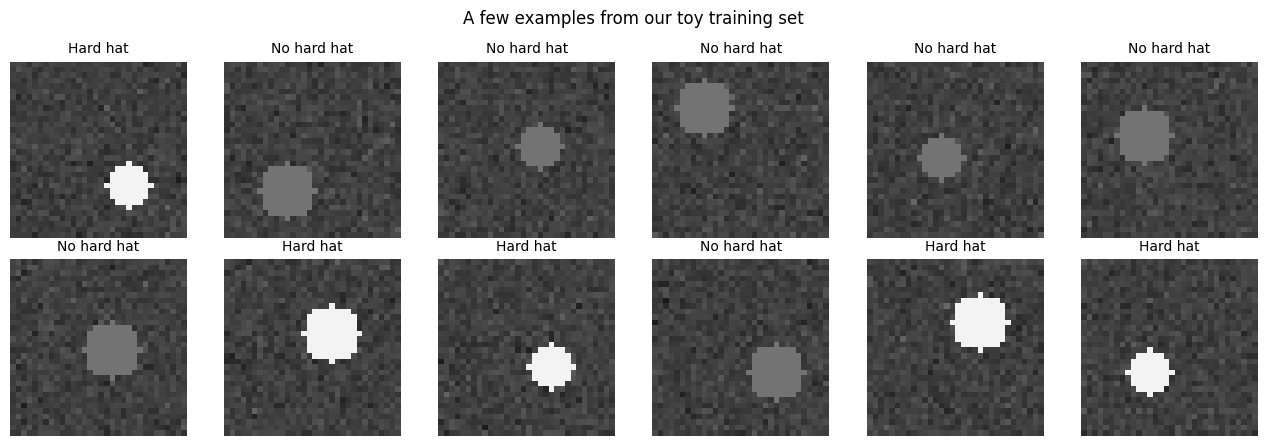

In [11]:

def make_helmet_dataset(n_samples, size=32, seed=0):
    '''Generates a toy dataset: small images containing either a bright
    "helmet" circle (label 1) or a dull "bare head" circle (label 0), at a
    random position, with a bit of background noise.'''
    rng = np.random.default_rng(seed)
    images = np.zeros((n_samples, size, size), dtype=np.float32)
    labels = np.zeros((n_samples,), dtype=np.int64)

    yy, xx = np.mgrid[0:size, 0:size]
    for i in range(n_samples):
        img = np.ones((size, size), dtype=np.float32) * 0.25
        img += rng.normal(0, 0.04, (size, size)).astype(np.float32)

        has_helmet = rng.integers(0, 2)
        cy = rng.integers(size // 4, size - size // 4)
        cx = rng.integers(size // 4, size - size // 4)
        r = rng.integers(size // 8, size // 5)
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

        img[mask] = 0.95 if has_helmet else 0.45
        images[i] = np.clip(img, 0, 1)
        labels[i] = has_helmet

    return images, labels

train_images, train_labels = make_helmet_dataset(300, seed=1)
test_images, test_labels = make_helmet_dataset(80, seed=2)

# Quick look at a handful of training examples
fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for ax, img, label in zip(axes.flat, train_images, train_labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title("Hard hat" if label == 1 else "No hard hat", fontsize=10)
    ax.axis('off')
plt.suptitle("A few examples from our toy training set")
plt.tight_layout()
plt.show()



In a real deployment you'd use thousands of *actual* site photos, carefully
labeled (often by a human reviewing past inspection footage). The model
training mechanics below are exactly the same regardless — only the data
changes.

Now let's define the CNN itself, using PyTorch (the most common deep
learning library). Compare this directly to the building-block diagram
above — you should be able to point to which line is "Convolution",
which is "Activation", and which is "Pooling".


In [12]:

class HelmetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: Convolution -> ReLU -> Pooling
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        # Block 2: Convolution -> ReLU -> Pooling
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected "decision" section
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)   # 2 output classes: "no helmet", "helmet"

    def forward(self, x, return_features=False):
        f1 = F.relu(self.conv1(x))
        p1 = self.pool1(f1)

        f2 = F.relu(self.conv2(p1))
        p2 = self.pool2(f2)

        flat = torch.flatten(p2, start_dim=1)
        h = F.relu(self.fc1(flat))
        out = self.fc2(h)

        if return_features:
            return out, f1, f2
        return out

model = HelmetCNN()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal learnable parameters: {n_params:,}")
print("(Compare this to a fully-connected network on the same image — it would need")
print(" millions of parameters for the first layer alone, as we calculated in Section 1)")


HelmetCNN(
  (conv1): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

Total learnable parameters: 36,290
(Compare this to a fully-connected network on the same image — it would need
 millions of parameters for the first layer alone, as we calculated in Section 1)



Now let's actually train it. "Training" just means: show the network
examples, measure how wrong its guesses are (the **loss**), and nudge every
weight a tiny bit in the direction that would have made it less wrong. Repeat
this thousands of times and the weights gradually settle into useful filters
— similar in spirit to the edge-detecting kernels from Section 5, except the
network *discovers* them itself rather than us hand-designing them.


In [13]:

# Convert our numpy arrays into the tensor format PyTorch expects:
# (batch_size, channels, height, width)
train_x = torch.tensor(train_images).unsqueeze(1)
train_y = torch.tensor(train_labels)
test_x = torch.tensor(test_images).unsqueeze(1)
test_y = torch.tensor(test_labels)

model = HelmetCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_function = nn.CrossEntropyLoss()

n_epochs = 25
history = {"loss": [], "test_acc": []}

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    predictions = model(train_x)
    loss = loss_function(predictions, train_y)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_predictions = model(test_x)
        test_accuracy = (test_predictions.argmax(dim=1) == test_y).float().mean().item()

    history["loss"].append(loss.item())
    history["test_acc"].append(test_accuracy)

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:2d}  |  training loss: {loss.item():.3f}  |  test accuracy: {test_accuracy*100:.1f}%")


Epoch  0  |  training loss: 0.709  |  test accuracy: 57.5%
Epoch  5  |  training loss: 0.672  |  test accuracy: 42.5%
Epoch 10  |  training loss: 0.648  |  test accuracy: 42.5%
Epoch 15  |  training loss: 0.595  |  test accuracy: 42.5%
Epoch 20  |  training loss: 0.499  |  test accuracy: 90.0%
Epoch 24  |  training loss: 0.404  |  test accuracy: 100.0%


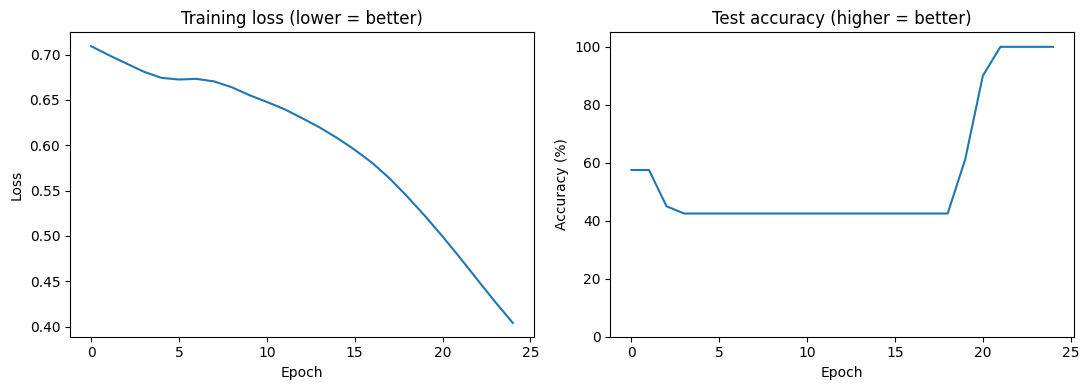

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["loss"])
axes[0].set_title("Training loss (lower = better)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot([a * 100 for a in history["test_acc"]])
axes[1].set_title("Test accuracy (higher = better)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 105)
plt.tight_layout()
plt.show()



You just trained a real CNN from scratch, in seconds, on your own laptop.
The loss should fall and the accuracy should climb toward ~95-100% — the
network has learned to tell "hard hat" from "no hard hat" purely from
examples, without us writing a single rule like "look for a bright circle."

### What did the network actually learn to look at?

Let's peek inside the trained model and visualize the **feature maps** —
the output of each convolution layer — for one example image. This is the
same idea as Section 5's hand-designed edge kernels, except now we're
looking at filters the network discovered on its own during training.


True label:      No hard hat
Model predicted: No hard hat


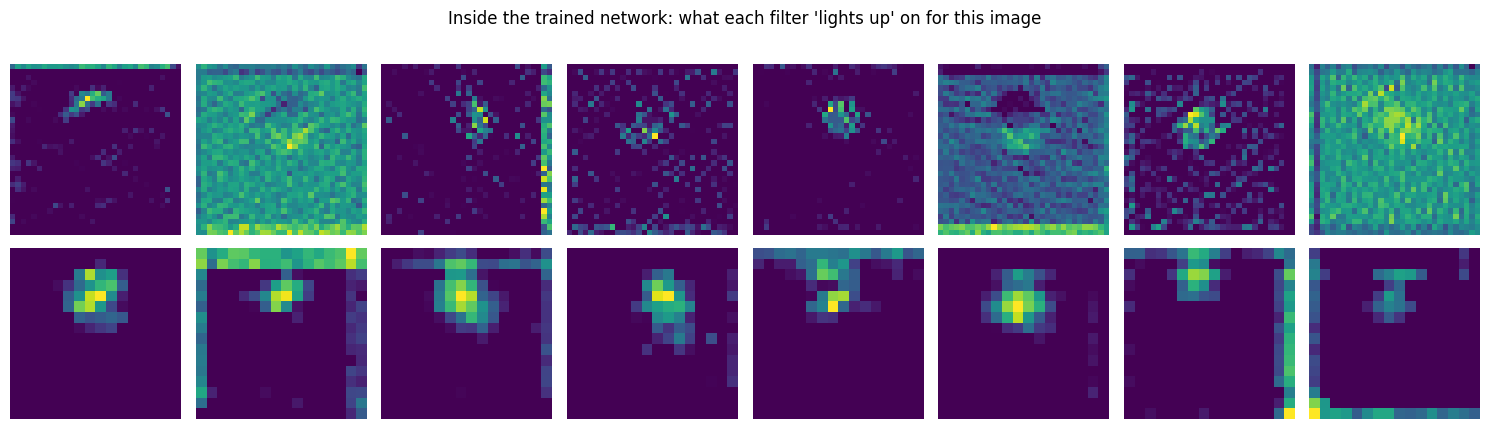

In [15]:

model.eval()
sample_image = test_x[0:1]   # take just one test image, keep batch dimension
sample_label = test_y[0].item()

with torch.no_grad():
    pred, feat1, feat2 = model(sample_image, return_features=True)
predicted_label = pred.argmax(dim=1).item()

print(f"True label:      {'Hard hat' if sample_label == 1 else 'No hard hat'}")
print(f"Model predicted: {'Hard hat' if predicted_label == 1 else 'No hard hat'}")

fig, axes = plt.subplots(2, 8, figsize=(15, 4.5))
for i in range(8):
    axes[0, i].imshow(feat1[0, i].numpy(), cmap='viridis')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel("Layer 1\nfeature maps", rotation=0, labelpad=60, fontsize=10)

for i in range(8):
    axes[1, i].imshow(feat2[0, i].numpy(), cmap='viridis')
    axes[1, i].axis('off')
axes[1, 0].set_ylabel("Layer 2\nfeature maps\n(first 8 of 16)", rotation=0, labelpad=60, fontsize=10)

plt.suptitle("Inside the trained network: what each filter 'lights up' on for this image")
plt.tight_layout()
plt.show()



Each small panel is one learned filter's response to the input image. Some
will look like simple edge detectors (similar to Section 5); others pick up
on blobs or contrast patterns specific to the helmet shape. By the second
convolution layer, the patterns are already noticeably more abstract — this
is the "edges → shapes → objects" progression mentioned in the lecture.

In a production PPE-detection system, this same architecture (just deeper,
trained on real labeled site photos, often building on a model already
pretrained on millions of general images) is what powers the bounding boxes
you'd see drawn around helmets, vests, and gloves in a live camera feed.



---
## 8. A guided tour of the famous CNN architectures

Everything above is the *complete* toolkit — convolution, activation,
pooling, fully connected layers. Every well-known CNN architecture from the
last decade is just a different recipe for stacking these same ingredients.
The differences are mostly about **depth, width, and a few clever tricks**
for training very deep networks without things falling apart.

This story is best told through a single competition: **ImageNet**, a
benchmark of 1.2 million labeled photos across 1,000 categories. Starting in
2012, an annual competition (the **ILSVRC**) challenged researchers to
classify these images with the lowest error rate. The architectures below
are the year-by-year winners — and the error rate dropped dramatically as
deep CNNs took over.


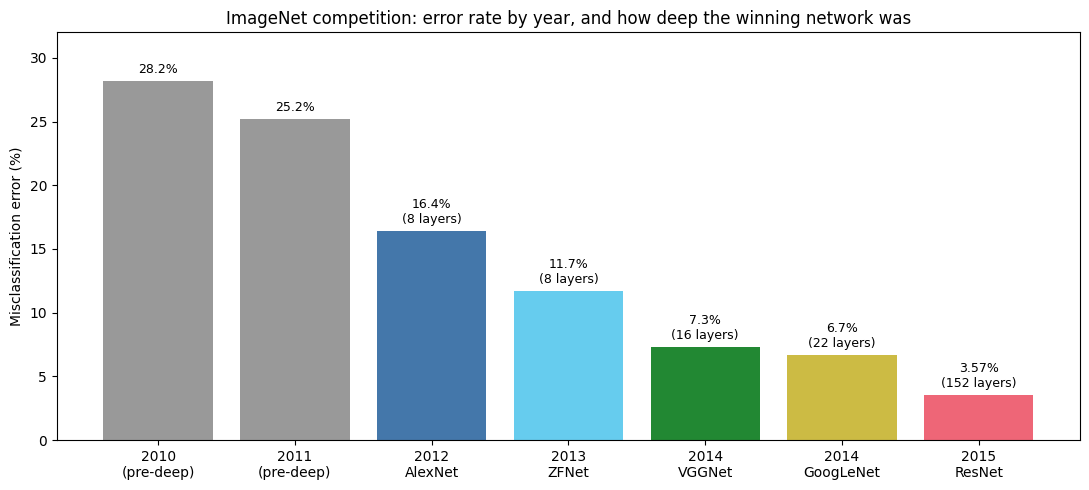

In [16]:

years   = ["2010\n(pre-deep)", "2011\n(pre-deep)", "2012\nAlexNet", "2013\nZFNet", "2014\nVGGNet", "2014\nGoogLeNet", "2015\nResNet"]
errors  = [28.2, 25.2, 16.4, 11.7, 7.3, 6.7, 3.57]
layers  = [None, None, 8, 8, 16, 22, 152]

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(years, errors, color=['#999999','#999999','#4477AA','#66CCEE','#228833','#CCBB44','#EE6677'])
ax1.set_ylabel("Misclassification error (%)")
ax1.set_title("ImageNet competition: error rate by year, and how deep the winning network was")
for bar, err, n_layers in zip(bars, errors, layers):
    label = f"{err}%" if n_layers is None else f"{err}%\n({n_layers} layers)"
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6, label,
              ha='center', fontsize=9)
ax1.set_ylim(0, 32)
plt.tight_layout()
plt.show()



Two trends jump out immediately:

1. The jump from 2011 to 2012 (25.2% → 16.4%) is **AlexNet** — the moment
   deep CNNs proved themselves and triggered the modern deep learning boom.
2. From there, error keeps falling roughly in step with **network depth**
   — 8 layers, then 16, then 22, then a staggering 152 layers by 2015
   (ResNet). Deeper networks could, in principle, learn richer, more
   layered representations — *if* you could actually train them, which
   turned out to be its own challenge (more on that shortly).

Let's walk through what each one actually changed.



### AlexNet (2012) — the one that started it all

AlexNet looks almost exactly like the LeNet-style network you just built and
trained above — just bigger, deeper, and trained on far more data and much
more powerful hardware (GPUs). Here is essentially the real AlexNet,
expressed the same way we built our `HelmetCNN` above:


In [17]:

alexnet_style = nn.Sequential(
    # Large 11x11 kernel with a big stride to quickly shrink a big 224x224 image
    nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    # Three convolution layers back-to-back, no pooling in between
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),

    nn.Flatten(),
    # Big fully-connected "decision" section, with Dropout to fight overfitting
    nn.Linear(6400, 4096), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(4096, 1000)   # 1000 ImageNet classes
)

n_params = sum(p.numel() for p in alexnet_style.parameters())
print(f"AlexNet-style network: {n_params:,} parameters")
print("(For comparison, our tiny HelmetCNN above had about 36 thousand)")


AlexNet-style network: 50,844,008 parameters
(For comparison, our tiny HelmetCNN above had about 36 thousand)



> **What's `Dropout`?** During training, dropout randomly switches off a
> fraction of neurons (here, 50%) on each pass. This forces the network to
> not over-rely on any single neuron, which helps fight overfitting —
> conceptually similar to a project team that cross-trains everyone on
> multiple tasks, so the project doesn't collapse if any one person is out.

### ZFNet (2013) — a small refinement

ZFNet kept AlexNet's overall shape but swapped the first layer's giant
11×11 kernels for smaller 7×7 ones. The idea: an oversized kernel applied
right at the start throws away fine detail too early — smaller kernels in
the first layer preserve more information for later layers to work with.

### VGGNet (2014) — go deep, keep it simple

VGGNet's contribution was almost philosophical: **stop hand-tuning kernel
sizes per layer** and just use 3×3 kernels and 2×2 max pooling *everywhere*,
stacked much deeper (16-19 layers). It turns out stacking small 3×3 kernels
gets you the same effective "field of view" as one big kernel, with fewer
parameters:

- Two 3×3 convolutions stacked back to back see a 5×5 area of the original image
- Three 3×3 convolutions stacked see a 7×7 area

VGG's main finding, confirmed by the chart above, was simply that **depth
itself** was a major driver of accuracy — deeper, simpler, uniform networks
beat shallower, more exotic ones.

### GoogLeNet (2014) — going wide instead of just deep, efficiently

GoogLeNet introduced two tricks worth knowing:

**1. The "Inception block"** — instead of picking one kernel size per
layer, run *several* kernel sizes (1×1, 3×3, 5×5) **side by side** on the
same input and concatenate their outputs. The network effectively gets to
use whichever kernel size works best for a given pattern, instead of us
guessing in advance.

**2. The 1×1 convolution** — a kernel that's just a single number per
channel. It sounds almost useless (it doesn't look at any neighboring
pixels at all!) but its real job is **cost control**: it can shrink the
*number of channels* cheaply before an expensive larger convolution runs,
without touching height or width at all.


In [18]:

# A 1x1 convolution in action: it doesn't blend neighboring pixels,
# it blends information *across channels*, at every pixel location independently.
input_3ch = torch.randn(1, 3, 4, 4)     # 1 image, 3 channels, 4x4 — like a tiny RGB patch
conv_1x1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=1)
output_1ch = conv_1x1(input_3ch)

print("Input shape: ", input_3ch.shape, " (3 channels)")
print("Output shape:", output_1ch.shape, " (squeezed down to 1 channel)")
print("\nHeight and width never changed — only the number of channels did.")
print("This is exactly how GoogLeNet keeps the expensive 3x3 and 5x5 convolutions")
print("affordable: shrink the channel count first with a cheap 1x1 conv, then")
print("run the bigger, more expensive kernel on the smaller version.")


Input shape:  torch.Size([1, 3, 4, 4])  (3 channels)
Output shape: torch.Size([1, 1, 4, 4])  (squeezed down to 1 channel)

Height and width never changed — only the number of channels did.
This is exactly how GoogLeNet keeps the expensive 3x3 and 5x5 convolutions
affordable: shrink the channel count first with a cheap 1x1 conv, then
run the bigger, more expensive kernel on the smaller version.



GoogLeNet also has one more neat trick at the very end: instead of
flattening its final 7×7×1024 feature maps into a huge fully-connected
layer (which would need roughly 49 million parameters — 7×7×1024×1000), it
runs a **global average pooling** — literally averaging each of the 1024
feature maps down to a single number. That alone collapses the output to a
tidy 1024 numbers, with a tiny fraction of the parameters.



---
## 9. ResNet (2015) — solving the "deeper should be better, but isn't" puzzle

The chart in Section 8 suggests a simple rule: more layers → better
accuracy. So why not just keep adding layers forever? Researchers tried —
and ran into a surprising wall.

### The puzzle

Suppose you've trained a decent network (call it $\mathcal{F}_1$) and it
works well. Now you make it deeper by adding more layers, getting a new
network $\mathcal{F}_2$. Logically, $\mathcal{F}_2$ should be *at least* as
good as $\mathcal{F}_1$ — worst case, the new layers could just learn to do
nothing (pass their input straight through unchanged), and you're back to
$\mathcal{F}_1$'s performance.

In practice, this is **not what happened**. Researchers found that simply
stacking more layers (a 56-layer plain network, for instance) often
performed *worse* — on both training and test data — than a shallower
version. The deeper network struggled to learn even the "do nothing, just
pass the input through" behavior. The deep layers were also prone to a
problem called **vanishing/exploding gradients**, where the training
signal becomes too small or too large to be useful as it travels back
through many layers.

### The fix: residual blocks

ResNet's idea is almost embarrassingly simple, once you see it: instead of
asking a block of layers to learn the full transformation $H(x)$ from
scratch, ask it to learn only the **residual** — the *difference* between
the desired output and the input, $F(x) = H(x) - x$ — and then **add the
original input back on** at the end:

$$\text{output} = F(x) + x$$

This small change, called a **skip connection**, means that if the best
thing a block can do is "nothing," it just needs to learn $F(x) = 0$ —
trivially easy — and the input passes straight through via the `+ x` path.
This turned out to make very deep networks dramatically easier to train.


In [19]:

class ResidualBlock(nn.Module):
    '''A minimal residual block: two convolutions, plus a "skip connection"
    that adds the original input back to the output.'''
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = F.relu(self.conv1(x))
        out = self.conv2(out)
        out = out + x          # <-- the skip connection: this is the entire trick
        return F.relu(out)

block = ResidualBlock(channels=4)
sample = torch.randn(1, 4, 8, 8)
output = block(sample)
print("Input shape: ", sample.shape)
print("Output shape:", output.shape, "(same shape — easy to stack many of these)")

n_params = sum(p.numel() for p in block.parameters())
print(f"Parameters in one residual block: {n_params:,}")


Input shape:  torch.Size([1, 4, 8, 8])
Output shape: torch.Size([1, 4, 8, 8]) (same shape — easy to stack many of these)
Parameters in one residual block: 296



That's the entire idea behind **ResNet152** — the 2015 ImageNet winner,
with 152 layers of weights, built almost entirely out of blocks like the
one above stacked end to end. It beat the previous year's best system by
16% on detection and 27% on localization, while still being trainable in
practice, thanks entirely to these skip connections.

You'll find this same "skip connection" trick (or close relatives of it)
inside almost every modern, very-deep computer vision model — it's one of
the most influential single ideas in the field.



---
## 10. Back to Bechtel: where this shows up in EPC work

Let's connect every concept back to the four use cases from Section 1.
In each case, the "famous architecture" details matter much less than the
core idea: **a CNN learns to recognize patterns by stacking small,
learned filters, going from edges → shapes → objects**, exactly as you
saw with our toy hard-hat classifier.

| Use case | What's really happening |
|---|---|
| **PPE detection** | A CNN very similar to the one you trained above — just deeper, and trained on real site photos — scans worker images and classifies/locates helmets, vests, gloves, masks |
| **Weld / corrosion / crack inspection** | Edge- and texture-detecting filters (like the ones in Section 5) pick out the sharp, irregular boundaries that distinguish a crack or corrosion patch from healthy material |
| **Document intelligence (P&IDs, datasheets, drawings)** | CNNs (often combined with OCR) detect symbols, lines, and text regions on scanned engineering drawings, turning unstructured paper into structured, searchable data |
| **Drone / remote sensing** | The same convolution + pooling stack runs over large aerial images to estimate progress, volumes, and site layout changes over time |

### A quick, hands-on extension: try it on a noisier, harder dataset

Real site photos are messier than our clean toy circles — variable
lighting, partial occlusion, cluttered backgrounds. Let's make the task
harder (more noise, smaller helmet/no-helmet contrast) and see how the same
network copes. This is a good way to build intuition for why real-world
deployments need more data, deeper networks, and careful evaluation.


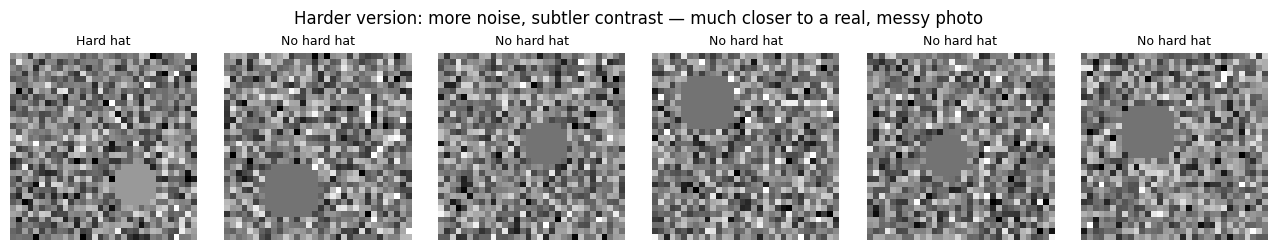

In [20]:

def make_harder_helmet_dataset(n_samples, size=32, seed=0, noise_level=0.12, contrast_gap=0.25):
    '''Same idea as before, but with more background noise and a smaller
    brightness gap between "helmet" and "no helmet" -- closer to how subtle
    real-world visual differences can be.'''
    rng = np.random.default_rng(seed)
    images = np.zeros((n_samples, size, size), dtype=np.float32)
    labels = np.zeros((n_samples,), dtype=np.int64)

    yy, xx = np.mgrid[0:size, 0:size]
    base = 0.5
    for i in range(n_samples):
        img = np.ones((size, size), dtype=np.float32) * base
        img += rng.normal(0, noise_level, (size, size)).astype(np.float32)

        has_helmet = rng.integers(0, 2)
        cy = rng.integers(size // 4, size - size // 4)
        cx = rng.integers(size // 4, size - size // 4)
        r = rng.integers(size // 8, size // 5)
        mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2

        img[mask] = base + (contrast_gap if has_helmet else -contrast_gap/2)
        images[i] = np.clip(img, 0, 1)
        labels[i] = has_helmet

    return images, labels

# Try changing noise_level and contrast_gap yourself and re-running this cell!
hard_train_x, hard_train_y = make_harder_helmet_dataset(300, seed=1, noise_level=0.20, contrast_gap=0.10)
hard_test_x, hard_test_y = make_harder_helmet_dataset(80, seed=2, noise_level=0.20, contrast_gap=0.10)

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
for ax, img, label in zip(axes, hard_train_x, hard_train_y):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title("Hard hat" if label == 1 else "No hard hat", fontsize=9)
    ax.axis('off')
plt.suptitle("Harder version: more noise, subtler contrast — much closer to a real, messy photo")
plt.tight_layout()
plt.show()


In [21]:

hard_train_x_t = torch.tensor(hard_train_x).unsqueeze(1)
hard_train_y_t = torch.tensor(hard_train_y)
hard_test_x_t = torch.tensor(hard_test_x).unsqueeze(1)
hard_test_y_t = torch.tensor(hard_test_y)

hard_model = HelmetCNN()
optimizer = torch.optim.Adam(hard_model.parameters(), lr=1e-3)

print("Training on the HARDER dataset...")
for epoch in range(40):
    hard_model.train()
    optimizer.zero_grad()
    preds = hard_model(hard_train_x_t)
    loss = loss_function(preds, hard_train_y_t)
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0 or epoch == 39:
        hard_model.eval()
        with torch.no_grad():
            test_preds = hard_model(hard_test_x_t)
            acc = (test_preds.argmax(dim=1) == hard_test_y_t).float().mean().item()
        print(f"Epoch {epoch:2d}  |  loss: {loss.item():.3f}  |  test accuracy: {acc*100:.1f}%")


Training on the HARDER dataset...
Epoch  0  |  loss: 0.699  |  test accuracy: 42.5%
Epoch 10  |  loss: 0.687  |  test accuracy: 42.5%
Epoch 20  |  loss: 0.674  |  test accuracy: 42.5%
Epoch 30  |  loss: 0.636  |  test accuracy: 72.5%
Epoch 39  |  loss: 0.627  |  test accuracy: 45.0%



Depending on how aggressive you set the noise and contrast values, you'll
likely see this version need more epochs, and land at a lower (sometimes
much lower) accuracy than our clean toy task. This mirrors a very real
lesson from deploying computer vision in the field: **data quality and
quantity usually matter more than architecture choice.** A simple CNN on
good, plentiful, representative data will usually beat a fancy architecture
trained on noisy or scarce data.

**Try it yourself:** go back to the cell above and experiment —
- Increase `noise_level` further (e.g. to 0.30) — how much further does accuracy drop?
- Shrink `contrast_gap` further (e.g. to 0.05) — at what point does the model basically fail?
- Increase the number of training samples (e.g. `n_samples=1500`) — does more data recover the accuracy?

This experimentation loop — change something, retrain, measure — is exactly
the day-to-day workflow of building a real computer-vision system.



---
## Summary: the whole lecture in one page

- **Fully connected networks don't scale to images** — too many parameters,
  and they ignore spatial structure.
- **Convolution** = slide a small kernel over the image, computing a
  windowed sum at each position. This is the core, reusable operation.
- **Padding** controls how much the image shrinks after each convolution;
  **stride** controls how far the kernel jumps each step.
- **Pooling** (usually max pooling) shrinks feature maps while keeping the
  strongest signals, and gives some tolerance to small shifts in position.
- **A CNN** = repeated [Convolution → ReLU → Pooling] blocks, finishing with
  a small fully-connected "decision" section. Training this stack on
  labeled examples lets the network *discover* useful filters on its own.
- **AlexNet → ZFNet → VGGNet → GoogLeNet → ResNet** is a story of going
  deeper and more efficient: bigger kernels swapped for smaller ones,
  uniform 3×3 stacks, parallel multi-scale "Inception" blocks with cheap
  1×1 convolutions for cost control, and finally residual/skip connections
  that made networks over 100 layers deep actually trainable.
- **In EPC terms:** this exact toolkit — convolution, pooling, learned
  filters — is what sits behind PPE detection, weld/corrosion/crack
  inspection, drawing and document intelligence, and drone-based progress
  monitoring. The "famous architecture" details are implementation
  choices; the underlying idea — learn local patterns, build them up into
  shapes and objects — is the one thing worth remembering.
